# **Machine Learning**

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
import sklearn

In [2]:
oecd_bli = pd.read_csv("/home/noneo/Codes/ML/MachineLearning/Datasets/oecd_bli_2015.csv", thousands=',')
gdp = pd.read_csv("/home/noneo/Codes/ML/MachineLearning/Datasets/gdp_per_capita.csv", thousands=',', delimiter='\t', encoding='latin1', na_values="n/a", index_col="Country")


In [3]:
oecd_bli

,LOCATION,Country,INDICATOR,Indicator,MEASURE,Measure,INEQUALITY,Inequality,Unit Code,Unit,PowerCode Code,PowerCode,Reference Period Code,Reference Period,Value,Flag Codes,Flags
0,AUS,Australia,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,1.10,E,Estimated value
1,AUT,Austria,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,1.00,NaN,NaN
2,BEL,Belgium,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,2.00,NaN,NaN
3,CAN,Canada,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,0.20,NaN,NaN
4,CZE,Czech Republic,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,0.90,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3287,EST,Estonia,WL_TNOW,Time devoted to leisure and personal care,L,Value,WMN,Women,HOUR,Hours,0,units,NaN,NaN,14.43,NaN,NaN
3288,ISR,Israel,WL_TNOW,Time devoted to leisure and personal care,L,Value,WMN,Women,HOUR,Hours,0,units,NaN,NaN,14.24,E,Estimated value
3289,RUS,Russia,WL_TNOW,Time devoted to leisure and personal care,L,Value,WMN,Women,HOUR,Hours,0,units,NaN,NaN,14.75,E,Estimated value
3290,SVN,Slovenia,WL_TNOW,Time devoted to leisure and personal care,L,Value,WMN,Women,HOUR,Hours,0,units,NaN,NaN,14.12,NaN,NaN


In [4]:
gdp

,Subject Descriptor,Units,Scale,Country/Series-specific Notes,2015,Estimates Start After
Country,,,,,,
Afghanistan,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",599.994,2013.0
Albania,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",3995.383,2010.0
Algeria,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",4318.135,2014.0
Angola,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",4100.315,2014.0
Antigua and Barbuda,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",14414.302,2011.0
...,...,...,...,...,...,...
Vietnam,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",2088.344,2012.0
Yemen,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",1302.940,2008.0
Zambia,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",1350.151,2010.0


In [5]:
oecd_bli["INEQUALITY"].unique()

array(['TOT', 'MN', 'WMN', 'HGH', 'LW'], dtype=object)

In [6]:
def prepare_country_stats(oecd_bli, gdp_per_capita):

    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"] == 'TOT']
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")

    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    # gdp_per_capita.set_index("Country", inplace=True)

    full_country_stats = pd.merge(
        left=oecd_bli,
        right=gdp_per_capita,
        left_index=True,
        right_index=True
    )

    full_country_stats.sort_values(by="GDP per capita", inplace=True)

    # Remove outliers (as done in book)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(len(full_country_stats))) - set(remove_indices))

    return full_country_stats.iloc[keep_indices][["GDP per capita", "Life satisfaction"]]

In [7]:
country_stats = prepare_country_stats(oecd_bli, gdp)

In [8]:
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

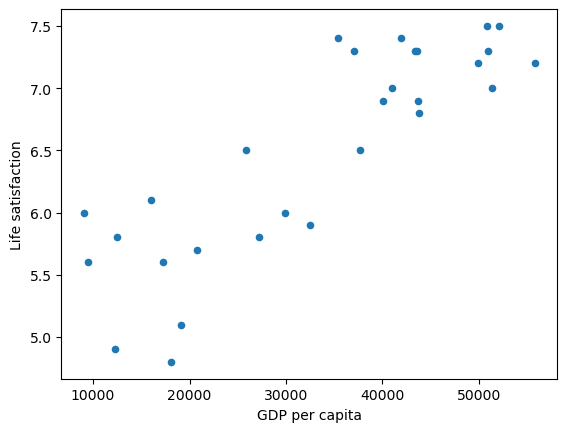

In [9]:
country_stats.plot(kind='scatter', x="GDP per capita", y='Life satisfaction')
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lin_reg_model = sklearn.linear_model.LinearRegression()

In [12]:
lin_reg_model.fit(X, y)

LinearRegression()

In [13]:
X_new = [[22587]]

In [14]:
print(lin_reg_model.predict(X_new))

[[5.96242338]]


# **Chapter 2:**

In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import sklearn

df = pd.read_csv(r"Datasets/housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [17]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [18]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [19]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

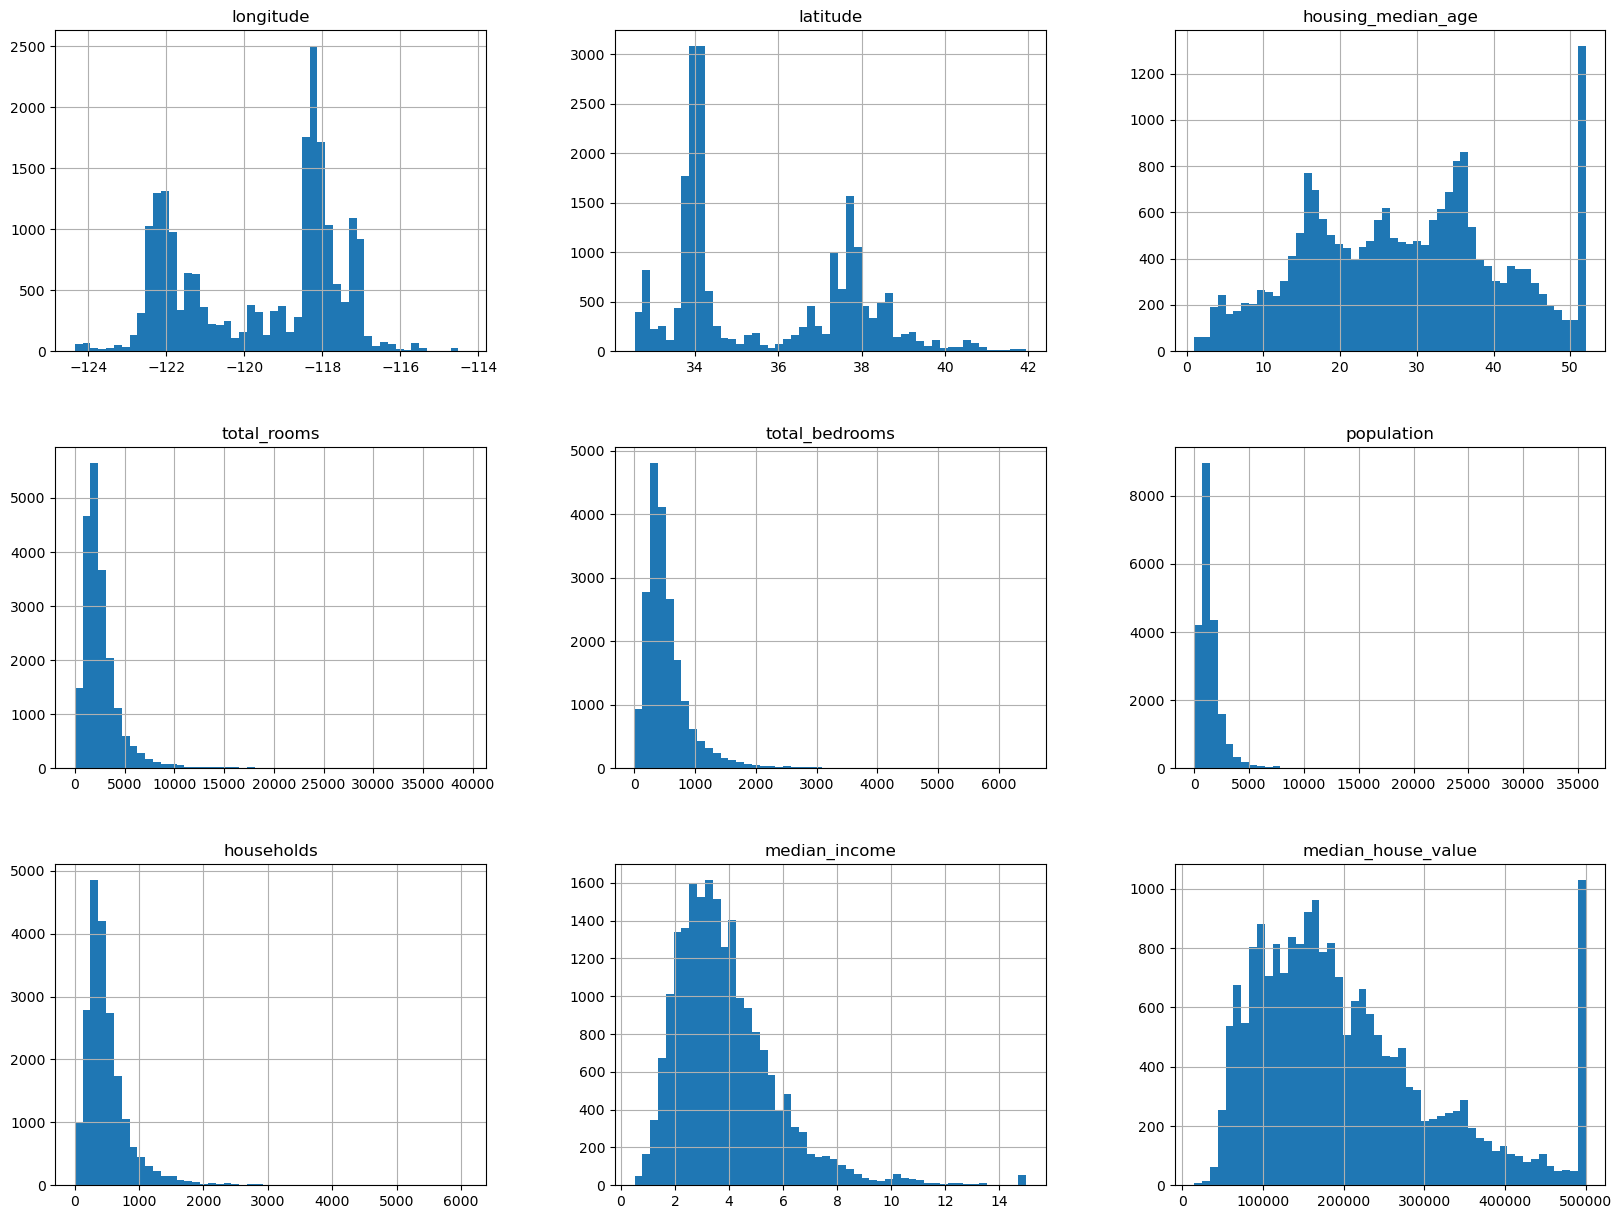

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
df.hist(bins=50 ,figsize=(20,15))
plt.show()

In [21]:
def split_train_test(data, test_ratio):    
    np.random.seed(42)
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio) # test_ratio = 0.2
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    
    return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = split_train_test(df, 0.2)
print(f"training set: {len(train_set)},    testing set: {len(test_set)}.")

training set: 16512,    testing set: 4128.


In [22]:
import hashlib

def test_set_check(identifier, test_ratio, hash):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

def split_train_test_by_id(data, test_ratio, id_column, hash=hashlib.md5):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio, hash))
    return data.loc[~in_test_set], data.loc[in_test_set]

housing_with_id = df.reset_index()
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, 'index')

test_set


,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
11,11,-122.26,37.85,52.0,3503.0,752.0,1504.0,734.0,3.2705,241800.0,NEAR BAY
20,20,-122.27,37.85,40.0,751.0,184.0,409.0,166.0,1.3578,147500.0,NEAR BAY
23,23,-122.27,37.84,52.0,1688.0,337.0,853.0,325.0,2.1806,99700.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...,...
20619,20619,-121.56,39.01,22.0,1891.0,340.0,1023.0,296.0,2.7303,99100.0,INLAND
20625,20625,-121.52,39.12,37.0,102.0,17.0,29.0,14.0,4.1250,72000.0,INLAND
20632,20632,-121.45,39.26,15.0,2319.0,416.0,1047.0,385.0,3.1250,115600.0,INLAND
20633,20633,-121.53,39.19,27.0,2080.0,412.0,1082.0,382.0,2.5495,98300.0,INLAND


In [23]:
housing_with_id['id'] = df['longitude'] * 1000 + df['latitude']
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, 'id')
train_set

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,-122192.12
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,-122182.14
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,-122202.15
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,-122212.15
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122212.15
...,...,...,...,...,...,...,...,...,...,...,...,...
20634,20634,-121.56,39.27,28.0,2332.0,395.0,1041.0,344.0,3.7125,116800.0,INLAND,-121520.73
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,-121050.52
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,-121180.57
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,-121280.57


In [24]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, random_state=42, test_size=0.2)

In [25]:
df['income_cat'] = np.ceil(df["median_income"] / 1.5)
df['income_cat'] = df['income_cat'].where(df["median_income"] < 5, 5.0)

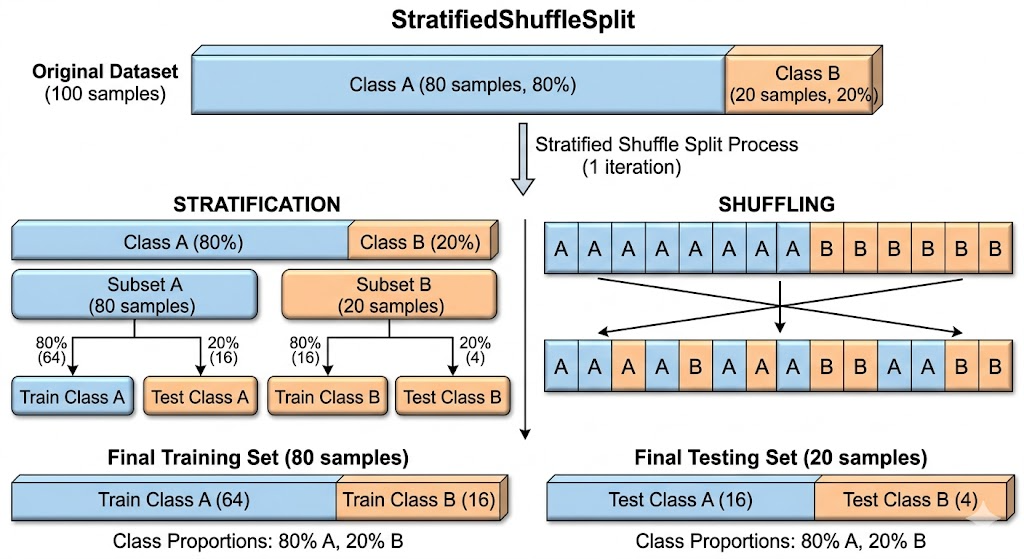

In [26]:
df['income_cat'].isna().sum()

0

In [27]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df , df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]


In [28]:
print(df["income_cat"].value_counts() / len(df))

print(len(df))

income_cat
3.0    0.350581
2.0    0.318847
5.0    0.218459
4.0    0.072287
1.0    0.039826
Name: count, dtype: float64
20640


In [29]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3.0
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,2.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,2.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,2.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,2.0


In [30]:
for set in (strat_train_set, strat_test_set):
    set.drop(["income_cat"], axis=1, inplace=True)
    

# **Discover and Visualize the Data to Gain Insights**

In [31]:
housing = strat_train_set.copy()

In [32]:
print(len(strat_train_set))
print(len(strat_test_set))

16512
4128


<Axes: xlabel='longitude', ylabel='latitude'>

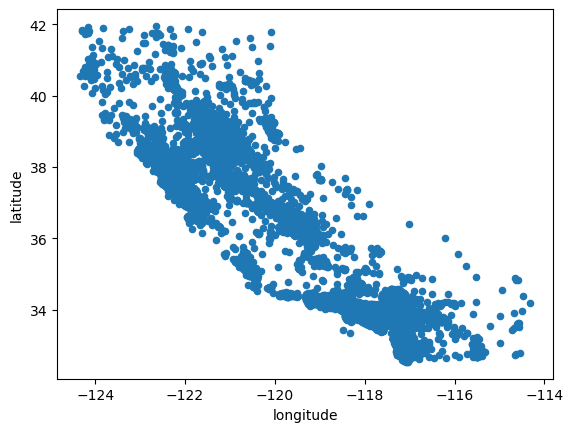

In [33]:
housing.plot(kind='scatter', x='longitude', y='latitude')

<Axes: xlabel='longitude', ylabel='latitude'>

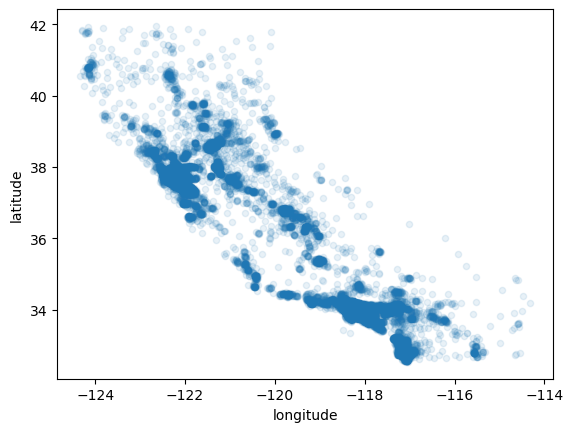

In [34]:
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.1)


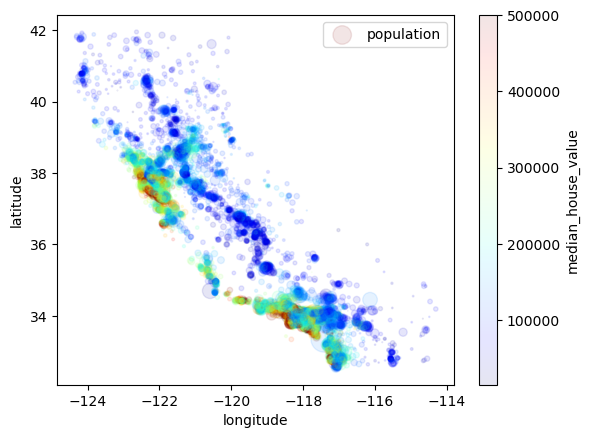

In [35]:
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.1, s=housing['population']/100,
             label='population', c="median_house_value", cmap=plt.get_cmap('jet'),
             colorbar=True)

plt.legend()


In [36]:
corr_matrix = housing.drop(['ocean_proximity'], axis=1).corr()

In [37]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687752
total_rooms           0.136422
housing_median_age    0.106985
households            0.066340
total_bedrooms        0.050081
population           -0.024622
longitude            -0.047586
latitude             -0.142814
Name: median_house_value, dtype: float64

In [38]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924389,-0.108155,0.047208,0.074522,0.106509,0.060606,-0.018869,-0.047586
latitude,-0.924389,1.000000,0.008553,-0.038805,-0.071377,-0.115141,-0.076244,-0.076833,-0.142814
housing_median_age,-0.108155,0.008553,1.000000,-0.363568,-0.322902,-0.298210,-0.304280,-0.118948,0.106985
total_rooms,0.047208,-0.038805,-0.363568,1.000000,0.929714,0.858039,0.919573,0.200166,0.136422
total_bedrooms,0.074522,-0.071377,-0.322902,0.929714,1.000000,0.877404,0.980592,-0.008189,0.050081
population,0.106509,-0.115141,-0.298210,0.858039,0.877404,1.000000,0.905679,0.004551,-0.024622
households,0.060606,-0.076244,-0.304280,0.919573,0.980592,0.905679,1.000000,0.012617,0.066340
median_income,-0.018869,-0.076833,-0.118948,0.200166,-0.008189,0.004551,0.012617,1.000000,0.687752
median_house_value,-0.047586,-0.142814,0.106985,0.136422,0.050081,-0.024622,0.066340,0.687752,1.000000


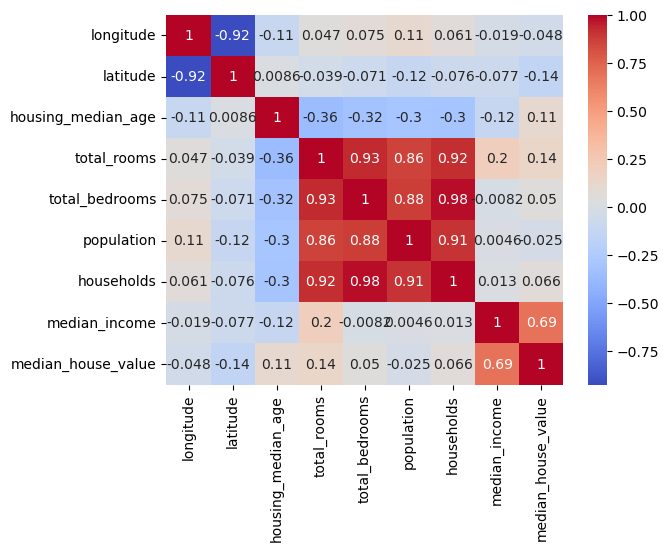

In [39]:
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

array([[<Axes: xlabel='housing_median_age', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='median_house_value', ylabel='housing_median_age'>],
       [<Axes: xlabel='housing_median_age', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='median_house_value', ylabel='total_rooms'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='median_house_value', ylabel='median_income'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='media

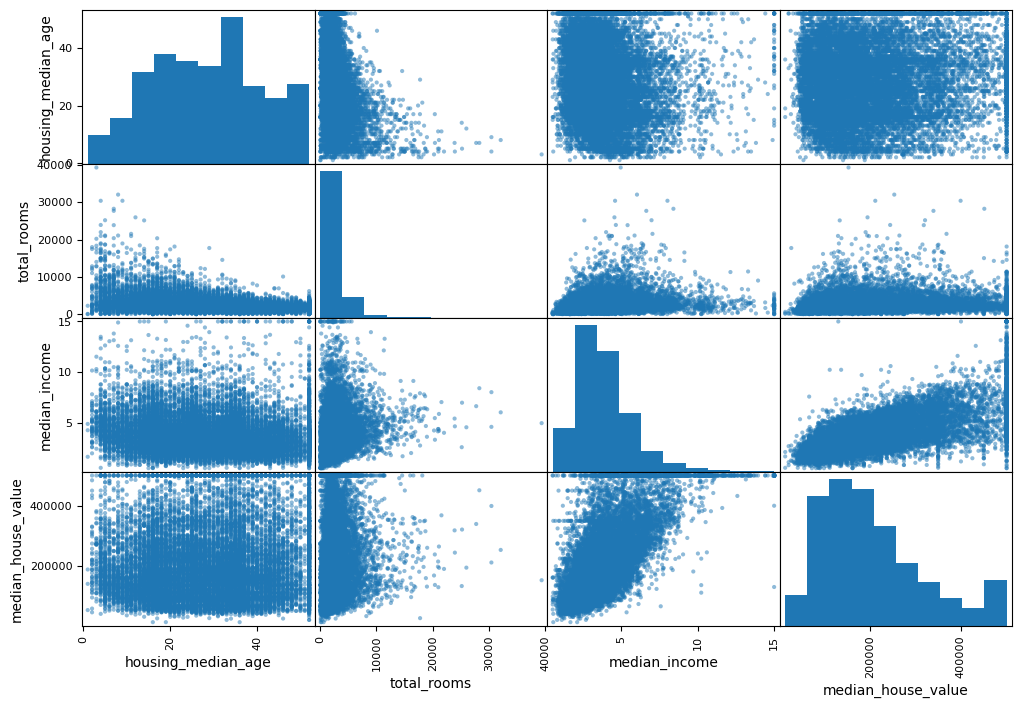

In [40]:
from pandas.plotting import scatter_matrix

attributes = [ 'housing_median_age', 'total_rooms',
               'median_income', 'median_house_value']
scatter_matrix(housing[attributes], figsize=(12,8))


<Axes: xlabel='median_income', ylabel='median_house_value'>

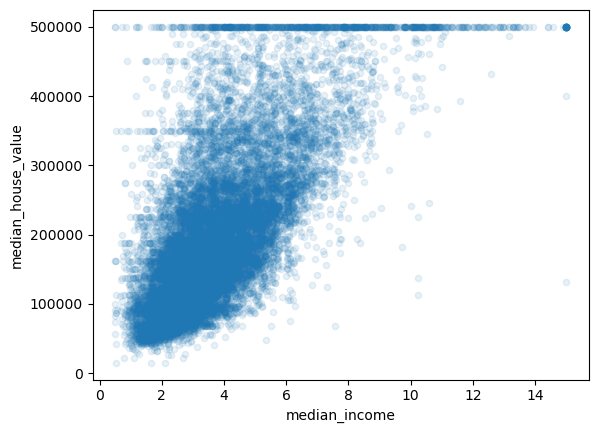

In [41]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
alpha=0.1)

In [42]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [43]:
corr_matrix = housing.drop(['ocean_proximity'], axis=1).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687752
rooms_per_household         0.145300
total_rooms                 0.136422
housing_median_age          0.106985
households                  0.066340
total_bedrooms              0.050081
population_per_household   -0.022435
population                 -0.024622
longitude                  -0.047586
latitude                   -0.142814
bedrooms_per_room          -0.258861
Name: median_house_value, dtype: float64

# **Prepare the Data for Machine Learning Algorithms**

In [44]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

## **Data Cleaning**

In [45]:
housing['total_bedrooms'].fillna(housing['total_bedrooms'].median()) 

17172     164.0
5293      656.0
14663     534.0
13986     619.0
16896     734.0
          ...  
19786     300.0
9969      393.0
14621    1051.0
9183     3945.0
11682    1615.0
Name: total_bedrooms, Length: 16512, dtype: float64

In [46]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")


In [47]:
housing_num = housing.drop("ocean_proximity", axis=1)
housing_num.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        159
population              0
households              0
median_income           0
dtype: int64

In [48]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

```
>>> imputer.statistics_
array([ -118.51 , 34.26 , 29. , 2119. , 433. , 1164. , 408. , 3.5414])
>>> housing_num.median().values
array([ -118.51 , 34.26 , 29. , 2119. , 433. , 1164. , 408. , 3.5414])
```

In [49]:
X = imputer.transform(housing_num)

In [50]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns)

In [51]:
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.26,37.38,28.0,1103.0,164.0,415.0,154.0,7.8633
1,-118.43,34.07,38.0,3251.0,656.0,1251.0,593.0,7.7382
2,-117.12,32.80,29.0,2863.0,534.0,1392.0,522.0,3.8719
3,-117.06,34.87,14.0,3348.0,619.0,1756.0,557.0,3.5987
4,-122.36,37.58,37.0,3325.0,734.0,1468.0,692.0,4.0987
...,...,...,...,...,...,...,...,...
16507,-122.86,40.56,12.0,1350.0,300.0,423.0,172.0,1.7393
16508,-122.48,38.51,49.0,1977.0,393.0,741.0,339.0,3.1312
16509,-117.17,32.78,17.0,3845.0,1051.0,3102.0,944.0,2.3658
16510,-118.55,34.41,8.0,21086.0,3945.0,9936.0,3790.0,5.8602


In [52]:
housing_tr.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

# **Handling Text and Categorical Attributes** 

In [53]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
housing_cat = housing["ocean_proximity"]
housing_cat_encoded = encoder.fit_transform(housing_cat)
housing_cat_encoded


array([4, 0, 4, ..., 4, 0, 0])

In [54]:
encoder.classes_

array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)

In [55]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
housing_cat_1hot = encoder.fit_transform(housing_cat_encoded.reshape(-1,1))
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

In [56]:
print(housing_cat_1hot)

  (0, 4)	1.0
  (1, 0)	1.0
  (2, 4)	1.0
  (3, 1)	1.0
  (4, 4)	1.0
  (5, 0)	1.0
  (6, 3)	1.0
  (7, 0)	1.0
  (8, 1)	1.0
  (9, 0)	1.0
  (10, 4)	1.0
  (11, 1)	1.0
  (12, 4)	1.0
  (13, 1)	1.0
  (14, 0)	1.0
  (15, 1)	1.0
  (16, 0)	1.0
  (17, 1)	1.0
  (18, 0)	1.0
  (19, 1)	1.0
  (20, 4)	1.0
  (21, 3)	1.0
  (22, 0)	1.0
  (23, 1)	1.0
  (24, 4)	1.0
  :	:
  (16487, 3)	1.0
  (16488, 3)	1.0
  (16489, 4)	1.0
  (16490, 0)	1.0
  (16491, 1)	1.0
  (16492, 3)	1.0
  (16493, 0)	1.0
  (16494, 1)	1.0
  (16495, 0)	1.0
  (16496, 1)	1.0
  (16497, 1)	1.0
  (16498, 0)	1.0
  (16499, 1)	1.0
  (16500, 0)	1.0
  (16501, 0)	1.0
  (16502, 1)	1.0
  (16503, 4)	1.0
  (16504, 1)	1.0
  (16505, 0)	1.0
  (16506, 0)	1.0
  (16507, 1)	1.0
  (16508, 1)	1.0
  (16509, 4)	1.0
  (16510, 0)	1.0
  (16511, 0)	1.0


In [57]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])

In [58]:
from sklearn.preprocessing import LabelBinarizer
encoder = LabelBinarizer()

housing_cat_1hot = encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1],
       ...,
       [0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0]])

You can get a sparse matrix
instead by passing sparse_output=True to the LabelBinarizer constructor.

### **Custom Transformers:**

In [59]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, household_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True):
        super().__init__()
        self.add_bedrooms_per_room = add_bedrooms_per_room
    
    def fit(self, X, y=None):
        return self # nothing else to do
    
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, household_ix]
        population_per_household = X[:, population_ix] / X[:, household_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, 
                         population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

## **Feature Scaling**

**Transformation PipeLines**

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

scaler = StandardScaler()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attr_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler())
])

housing_num_tr = num_pipeline.fit_transform(housing_num)

In [61]:
class DataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.attribute_names].values

In [62]:
from sklearn.pipeline import FeatureUnion

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

num_pipeline = Pipeline([
    ('selector', DataFrameSelector(num_attribs)),
    ('imputer', SimpleImputer(strategy='median')),
    ('attr_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('selector', DataFrameSelector(cat_attribs)),
    ('label_Binarizer', OneHotEncoder())
])

full_pipeline = FeatureUnion(transformer_list=[
    ('num_pipeline', num_pipeline),
    ('cat_pipeline', cat_pipeline)
])


housing_prepared = full_pipeline.fit_transform(housing)


In [63]:
housing_prepared.toarray()

array([[-1.34061366,  0.81549736, -0.04911198, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.57167919, -0.73324997,  0.7474863 , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.22575325, -1.32748233,  0.03054785, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 1.20078859, -1.33684032, -0.92537009, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.51176401, -0.57416414, -1.64230855, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.78138233, -0.82682987, -0.28809147, ...,  0.        ,
         0.        ,  0.        ]])

In [64]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(housing_prepared, housing_labels)

LinearRegression()

## **Training and Evaluating on the Training Set**

In [65]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

In [66]:
print("Predictions:\t", lr.predict(some_data_prepared))
print("Labels:\t\t", list(some_labels))

Predictions:	 [396659.12545159 411472.22619443 228454.13687045  96705.72102078
 289523.91327304]
Labels:		 [500001.0, 500001.0, 174200.0, 91400.0, 434000.0]


## **Error**

In [67]:
from sklearn.metrics import mean_squared_error

housing_predictions = lr.predict(housing_prepared)
lr_mse = mean_squared_error(housing_labels, housing_predictions)
lr_rmse = np.sqrt(lr_mse)

In [68]:
lr_rmse

68501.96465501093

**Decision Trees are presented in more detail in Chapter 6**

In [69]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor()

In [70]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

0.0

# **Better Evaluation Using Cross-Validation**

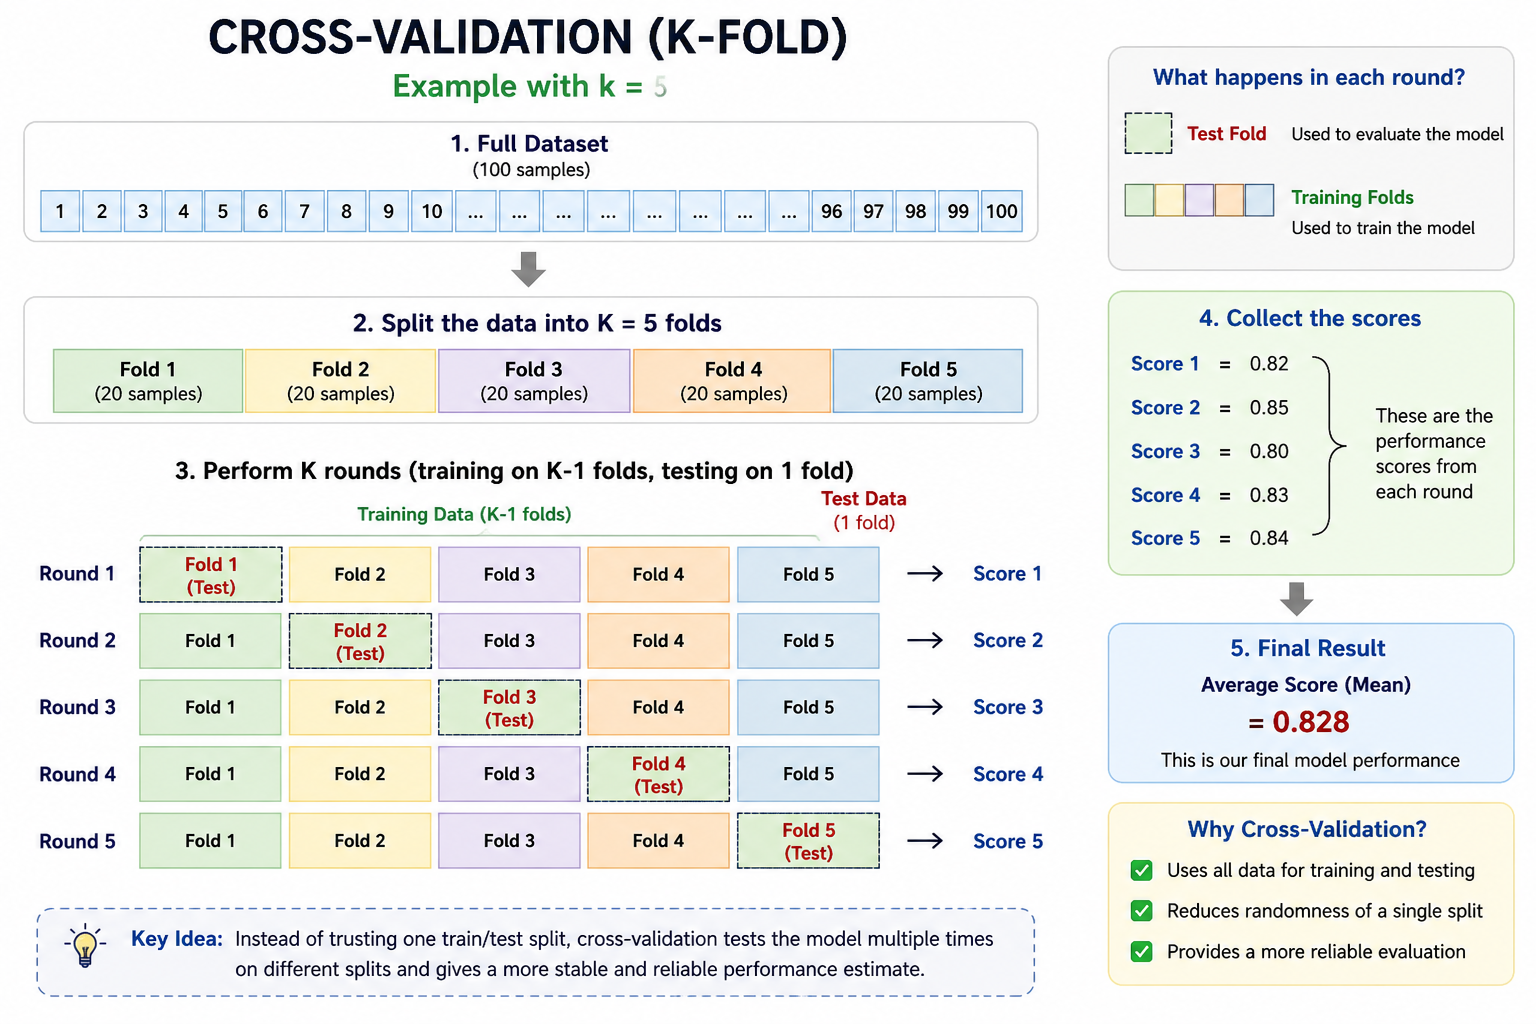

In [71]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    tree_reg, housing_prepared, housing_labels,
    scoring="neg_mean_squared_error", cv=10
)
rmse_scores = np.sqrt(-scores)

In [72]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
    
display_scores(rmse_scores)

Scores: [73091.47822936 72201.30265027 73520.8731725  70629.26543638
 73440.71822115 73905.92627625 71436.93824893 71593.3478703
 72845.86279196 70656.6336408 ]
Mean: 72332.23465379006
Standard deviation: 1141.523664771716


In [73]:
lr_scores = cross_val_score(
    lr, housing_prepared, housing_labels,
    scoring="neg_mean_squared_error", cv=10
)
lr_rmse_scores = np.sqrt(-lr_scores)

display_scores(lr_rmse_scores)

Scores: [66430.8459326  64703.73527883 66823.35889085 72590.89602851
 68485.97550805 72106.95905958 67827.46887761 68914.80128581
 70366.48357786 70183.29246033]
Mean: 68843.38169000272
Standard deviation: 2387.7272305905212


In [74]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)


RandomForestRegressor()

In [75]:
housing_predictions = forest_reg.predict(housing_prepared)

mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(mse)
display_scores(forest_rmse)

Scores: 18889.692838572682
Mean: 18889.692838572682
Standard deviation: 0.0


In [76]:
import joblib
joblib.dump(forest_reg, "my_model.pkl")
my_model_loaded = joblib.load("my_model.pkl")

## **Fine Tuning:**

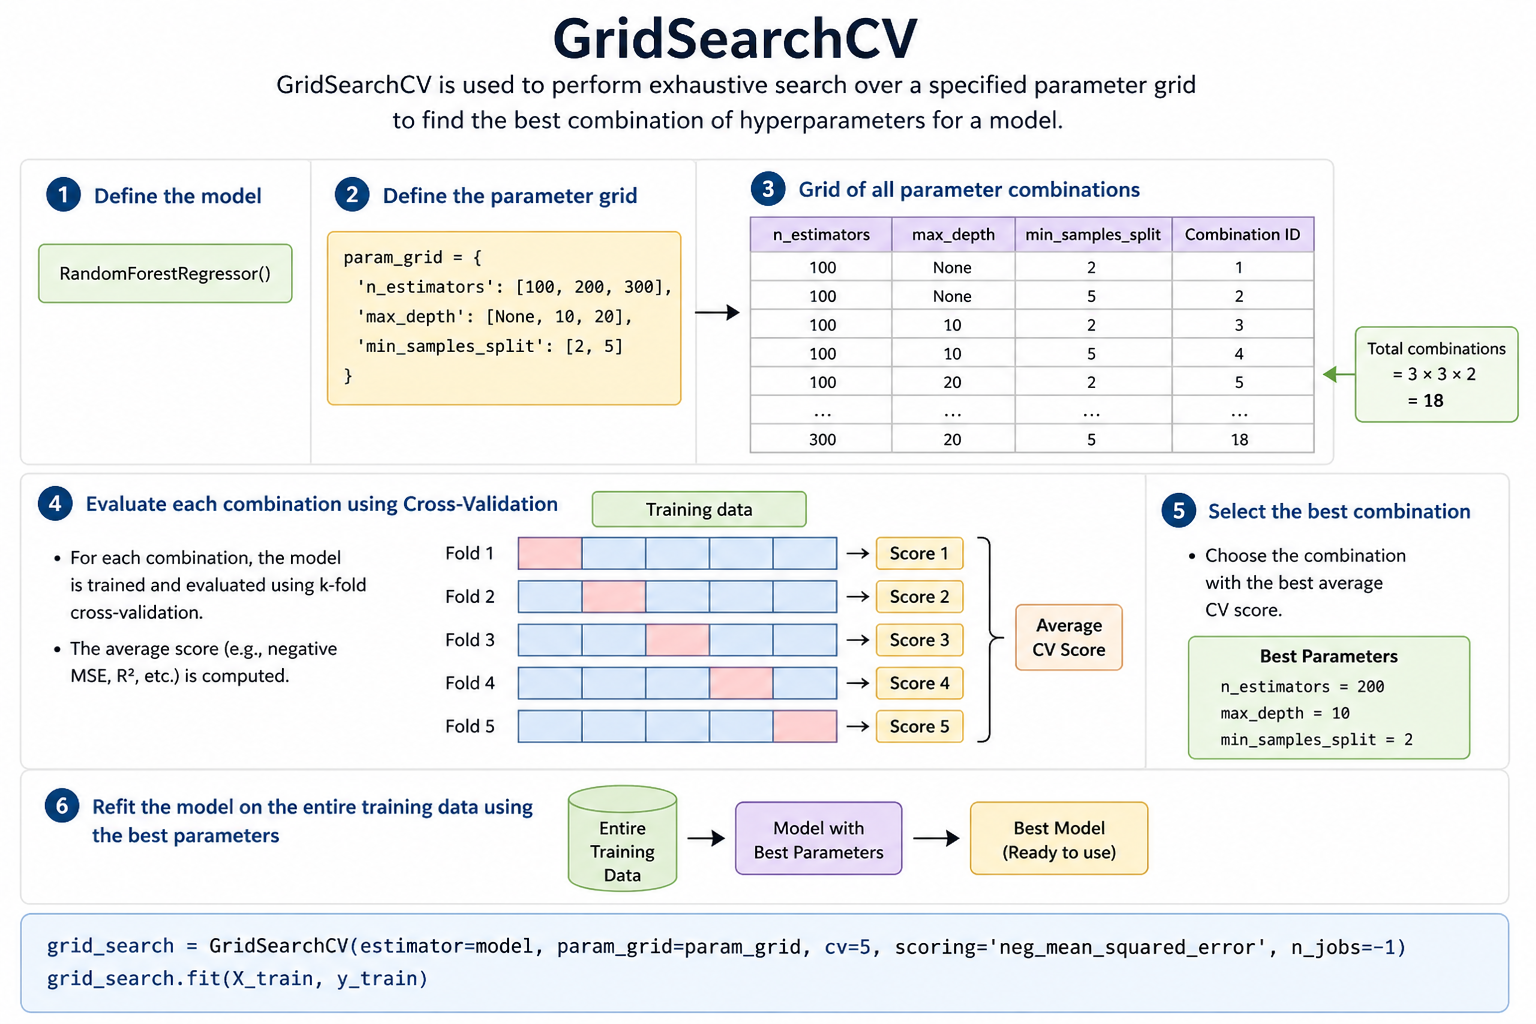

In [77]:
from sklearn.model_selection import GridSearchCV
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]
forest_reg = RandomForestRegressor()

grid_search = GridSearchCV(
    forest_reg, param_grid, cv=5,
    scoring='neg_mean_squared_error'
)
grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             scoring='neg_mean_squared_error')

In [78]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

In [79]:
grid_search.best_estimator_

RandomForestRegressor(max_features=6, n_estimators=30)

In [80]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

64923.73519093428 {'max_features': 2, 'n_estimators': 3}
55909.90779175364 {'max_features': 2, 'n_estimators': 10}
53384.553241773785 {'max_features': 2, 'n_estimators': 30}
60431.93103078335 {'max_features': 4, 'n_estimators': 3}
53178.076029035066 {'max_features': 4, 'n_estimators': 10}
50891.77070911321 {'max_features': 4, 'n_estimators': 30}
59588.39228999266 {'max_features': 6, 'n_estimators': 3}
52852.46025957934 {'max_features': 6, 'n_estimators': 10}
50503.85916894236 {'max_features': 6, 'n_estimators': 30}
58876.688243616794 {'max_features': 8, 'n_estimators': 3}
52530.74259590931 {'max_features': 8, 'n_estimators': 10}
50625.854923584826 {'max_features': 8, 'n_estimators': 30}
62593.64210373608 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54875.945692084715 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60938.761687513805 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52786.21409295213 {'bootstrap': False, 'max_features': 3, 'n_estimator

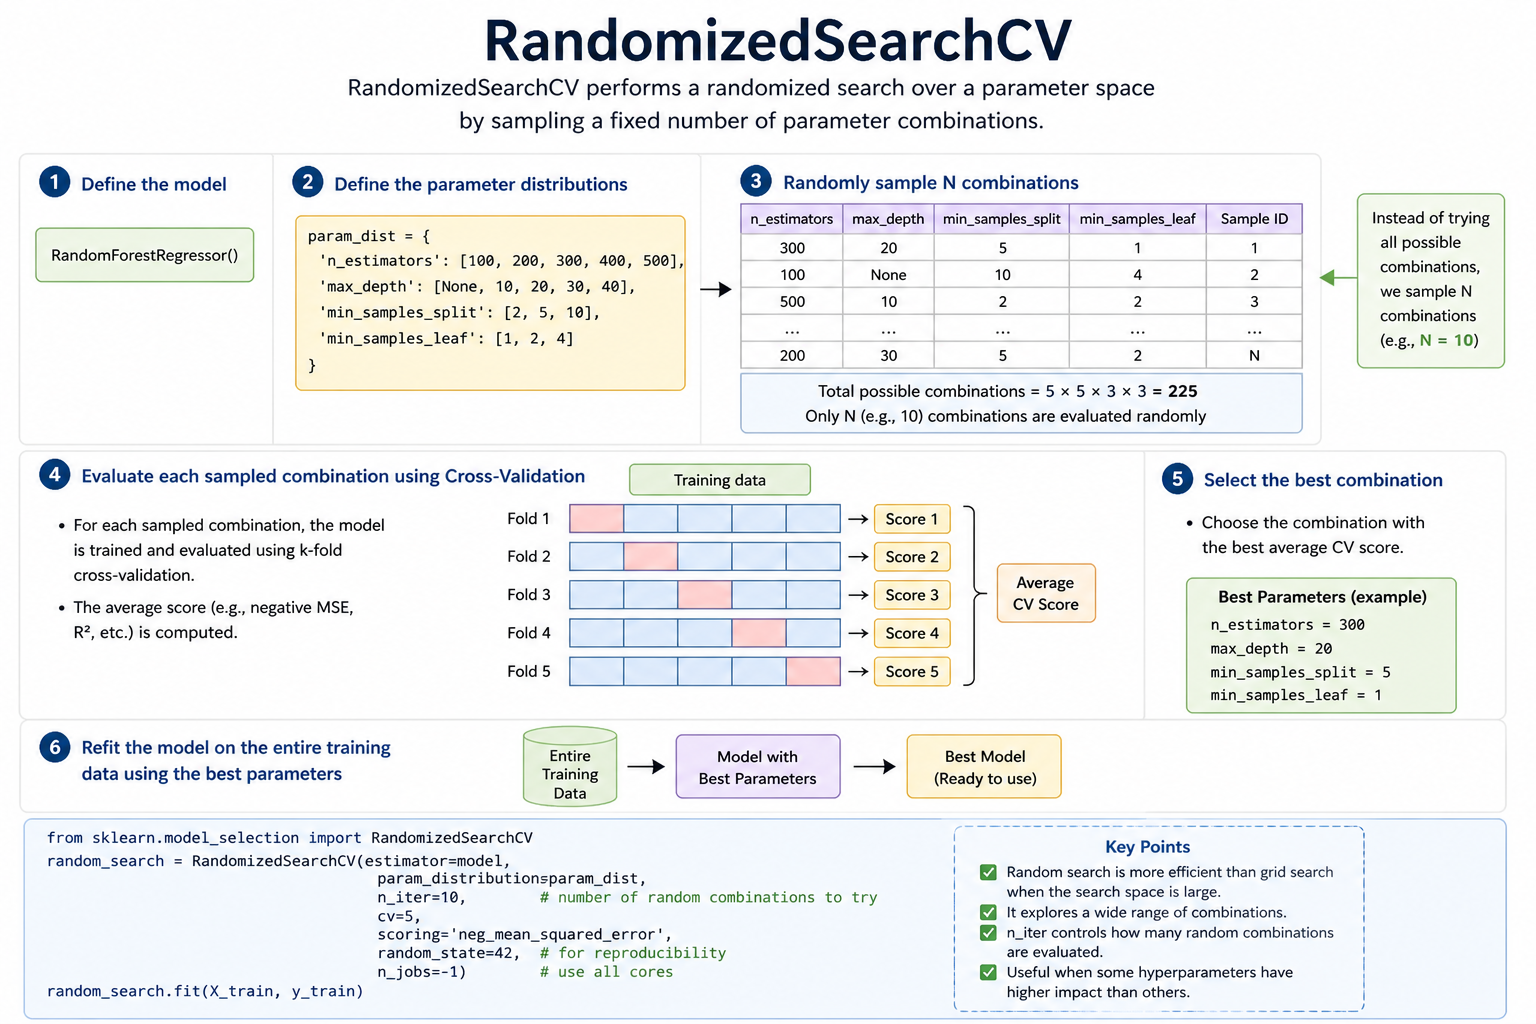

In [90]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [92]:
param_distribs = [
    {'n_estimators': randint(low=1, high=200), 
     'max_features': randint(low=1, high=8), },
]

In [93]:

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
rnd_search.fit(housing_prepared, housing_labels)

KeyboardInterrupt: 

In [94]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

AttributeError: 'RandomizedSearchCV' object has no attribute 'cv_results_'

In [ ]:
feature_importances = grid_search.best_estimator_.feature_importances_

In [ ]:
feature_importances

array([7.01983163e-02, 6.66328141e-02, 4.35363219e-02, 1.83336438e-02,
       1.68019087e-02, 1.80292305e-02, 1.63175206e-02, 3.55724622e-01,
       4.85305772e-02, 1.10481783e-01, 7.35204443e-02, 1.34329976e-02,
       1.40814776e-01, 7.84265431e-05, 3.01121108e-03, 4.55540633e-03])

In [ ]:
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_one_hot_attribs = list(encoder.classes_)
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(0.3557246223723908, 'median_income'),
 (0.14081477624819666, 'INLAND'),
 (0.1104817826136717, 'pop_per_hhold'),
 (0.0735204442769419, 'bedrooms_per_room'),
 (0.07019831626822975, 'longitude'),
 (0.06663281405066042, 'latitude'),
 (0.048530577150626815, 'rooms_per_hhold'),
 (0.0435363218935582, 'housing_median_age'),
 (0.01833364375209602, 'total_rooms'),
 (0.0180292305069047, 'population'),
 (0.016801908686031472, 'total_bedrooms'),
 (0.01631752059848919, 'households'),
 (0.013432997633157414, '<1H OCEAN'),
 (0.004555406325749843, 'NEAR OCEAN'),
 (0.0030112110802330127, 'NEAR BAY'),
 (7.84265430620728e-05, 'ISLAND')]

In [ ]:
final_model = grid_search.best_estimator_
final_model

RandomForestRegressor(max_features=6, n_estimators=30)

In [ ]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()
X_test_prepared = full_pipeline.transform(X_test)

In [ ]:
final_predictions = final_model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

In [ ]:
final_rmse

47094.369364225226